### 0️. Importar Librerias

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from sklearn.decomposition import PCA

In [3]:
# Para que se muestren todas las columnas al inspeccionar los DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)


In [4]:
from framework import sp_carga_exploracion as sc
from framework import sp_limpieza_transformacion as sl
from framework import sp_eda as se
from framework import sp_abtest as sb
from framework import sp_modelado as sm
from framework import sp_clustering as cl

### 1️. Cargar DataFrame / modelos

In [5]:
escuela = sm.cargar_csv(
    '../data/processed/03_datos_eda.csv'
)

CSV CARGADO
Archivo: ../data/processed/03_datos_eda.csv
Filas:   1000
Columnas: 14


In [7]:
# trabajar solamente con las variables numéricas continuas:
variables_cluster = [
    'horas_estudio_semanal',
    'nota_anterior',
    'tasa_asistencia',
    'horas_sueno',
    'edad'
]

X_cluster = escuela[
    variables_cluster
].copy()

### 2. Preparacion de datos 

In [10]:
X_cluster, scaler = (
    cl.estandarizar_clustering(
        X_cluster
    )
)

In [11]:
X_cluster.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
horas_estudio_semanal,1000.0,-0.0,1.0,-1.87,-0.71,-0.01,0.68,3.08
nota_anterior,1000.0,0.0,1.0,-2.72,-0.68,0.01,0.70,2.05
tasa_asistencia,1000.0,-0.0,1.0,-2.97,-0.69,0.06,0.80,1.43
horas_sueno,1000.0,0.0,1.0,-2.26,-0.61,0.00,0.61,2.25
edad,1000.0,-0.0,1.0,-1.59,-0.73,0.13,1.00,1.57


### Conclusiones

Se estandarizan las variables seleccionadas para clustering mediante StandardScaler.

La estandarización es necesaria porque K-Means utiliza distancias y todas las variables deben encontrarse en la misma escala.

Variables utilizadas:

- horas_estudio_semanal
- nota_anterior
- tasa_asistencia
- horas_sueno
- edad

Tras la transformación, todas las variables presentan media cercana a 0 y desviación estándar cercana a 1.

### 2. ELEGIR NÚMERO DE CLUSTERS

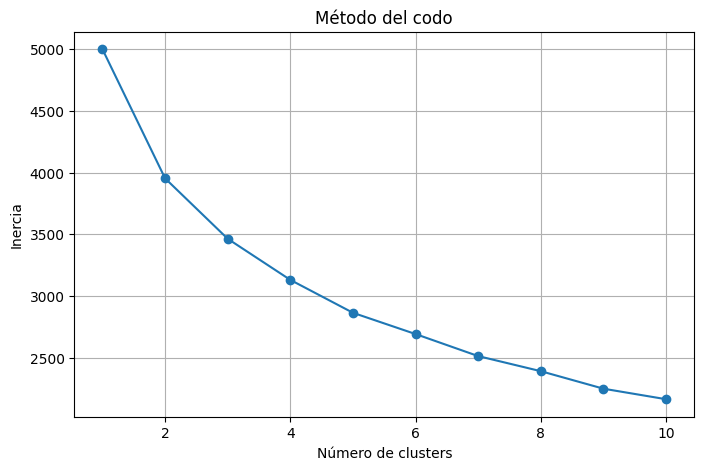

In [12]:
inercias = cl.metodo_codo(
    X_cluster,
    k_max=10
)

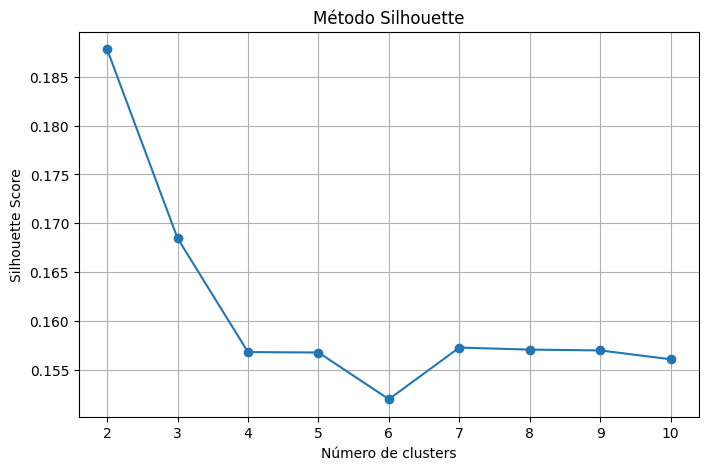

Mejor k: 2
2
0.18780273079656057


In [13]:
mejor_k, score = cl.metodo_silhouette(
    X_cluster,
    k_max=10
)

print(mejor_k)
print(score)

In [14]:
# Opción recomendada por Silhouette
modelo_2, labels_2 = cl.entrenar_kmeans(
    X_cluster,
    n_clusters=2
)

# Opción recomendada por el Codo
modelo_3, labels_3 = cl.entrenar_kmeans(
    X_cluster,
    n_clusters=3
)


In [15]:
cl.evaluar_clustering(
    X_cluster,
    labels_2,
    modelo_2
)

{'Silhouette': 0.18780273079656057,
 'Davies_Bouldin': 1.8593162080569292,
 'Inercia': 3953.7369233238687}

In [16]:
cl.evaluar_clustering(
    X_cluster,
    labels_3,
    modelo_3
)

{'Silhouette': 0.16848221172631964,
 'Davies_Bouldin': 1.7797918885164892,
 'Inercia': 3464.1116363571737}

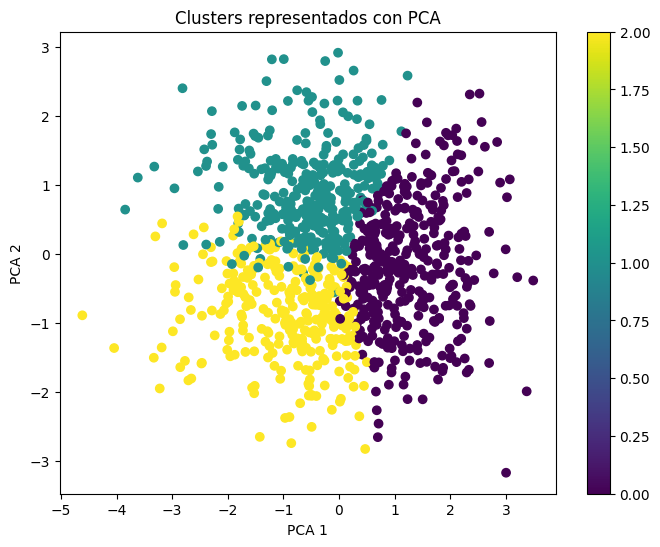

In [21]:
cl.visualizar_clusters_pca(
    X_cluster,
    labels_3
)

In [18]:
perfil_2 = cl.perfil_clusters(
   escuela[variables_cluster],
    labels_2
)

perfil_3 = cl.perfil_clusters(
    escuela[variables_cluster],
    labels_3
)

display(perfil_2)
display(perfil_3)

,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad
Cluster,,,,,
0,12.89,80.25,83.24,7.17,23.55
1,7.42,60.12,65.28,6.85,23.51


,horas_estudio_semanal,nota_anterior,tasa_asistencia,horas_sueno,edad
Cluster,,,,,
0,13.76,82.01,84.61,7.22,23.34
1,7.88,62.26,71.24,7.40,26.35
2,7.88,63.15,63.62,6.30,20.57


In [19]:
escuela['cluster'] = labels_3

In [20]:
escuela.groupby('cluster')[
    ['nota_final', 'aprobado_ml']
].mean()

,nota_final,aprobado_ml
cluster,,
0,77.341555,0.981233
1,68.030539,0.844311
2,67.818430,0.853242


Cluster 0
- Mucho estudio
- Buena nota previa
- Alta asistencia

Cluster 1
- Poco estudio
- Peor nota previa
- Menor asistencia

k = 3

Cluster 0
Alto rendimiento

Horas estudio: 13.76
Nota anterior: 82.01
Asistencia:    84.61

Nota final:    77.34
Aprobados:     98.1%

Se aplicó K-Means sobre variables académicas y de comportamiento:

- horas_estudio_semanal
- nota_anterior
- tasa_asistencia
- horas_sueno
- edad

Aunque el método Silhouette sugiere k=2, la solución de k=3 aporta una segmentación más rica e interpretable.

Se identifican tres perfiles principales:

1. Estudiantes de alto rendimiento.
2. Estudiantes maduros con rendimiento medio.
3. Estudiantes jóvenes con menor asistencia y mayor riesgo académico.

La segmentación obtenida es coherente con los hallazgos previos del EDA, AB Testing, Regresión y Clasificación, reforzando la importancia de la asistencia, la nota previa y los hábitos de estudio en el rendimiento académico.

### Conclusiones del Clustering

Se aplicó K-Means sobre las variables:

- horas_estudio_semanal
- nota_anterior
- tasa_asistencia
- horas_sueno
- edad

Tras evaluar distintas configuraciones mediante el Método del Codo y el índice Silhouette, se analizaron soluciones con 2 y 3 clusters.

Aunque el índice Silhouette favorece ligeramente la solución de 2 clusters, la segmentación con 3 clusters proporciona una interpretación más rica y útil desde el punto de vista académico.

#### Cluster 0: Alto rendimiento

- Mayor número de horas de estudio.
- Mejor nota previa.
- Mayor asistencia.
- Nota final media: 77.34.
- Tasa de aprobados: 98.1%.

#### Cluster 1: Rendimiento medio

- Rendimiento académico intermedio.
- Mayor edad media.
- Asistencia moderada.
- Nota final media: 68.03.
- Tasa de aprobados: 84.4%.

#### Cluster 2: Grupo de riesgo académico

- Menor asistencia.
- Menos horas de sueño.
- Menor edad media.
- Nota final media: 67.82.
- Tasa de aprobados: 85.3%.

#### Conclusión general

Los resultados refuerzan los hallazgos obtenidos durante el EDA, el AB Testing, la Regresión y la Clasificación.

Las variables más influyentes en la segmentación de estudiantes son:

- Horas de estudio semanal.
- Nota anterior.
- Tasa de asistencia.

Estas variables aparecen de forma consistente en todos los análisis realizados durante el proyecto.